In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/train.csv')
print(df.head())

<bound method NDFrame.head of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Util

In [3]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
df['SalePrice'].describe()
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [5]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

zero_cols = ['GarageYrBlt', 'MasVnrArea']

for col in zero_cols:
    df[col] = df[col].fillna(0)

df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [6]:
df.isnull().sum().sum()

np.int64(0)

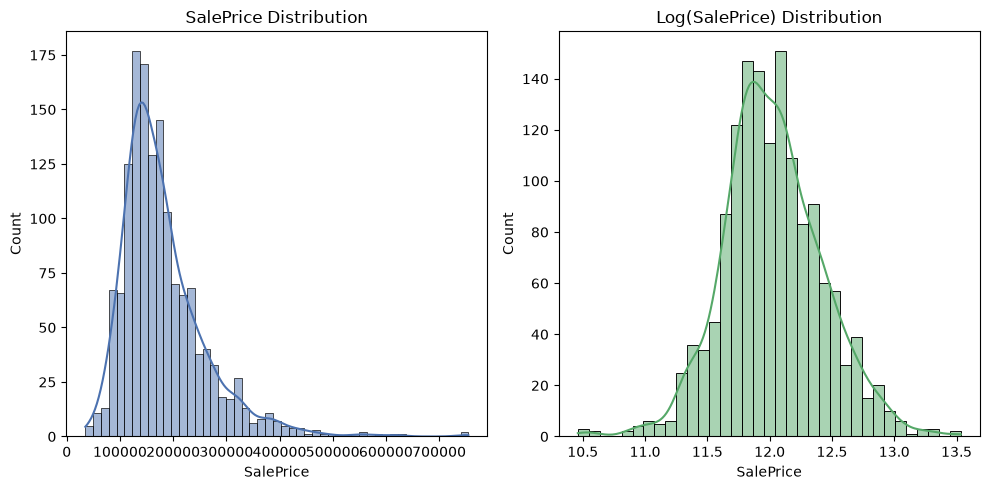

In [7]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(df['SalePrice'], kde=True, color='#4C72B0')
plt.title('SalePrice Distribution')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['SalePrice']), kde=True, color='#55A868')
plt.title('Log(SalePrice) Distribution')

plt.tight_layout()
plt.savefig('images/saleprice_distribution.png', dpi=200)
plt.show()


In [8]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])

In [ ]:
X = df.drop(['SalePrice', 'Id', "SalePrice_log"], axis = 1)
Y = df['SalePrice_log']

# Numeric and categorical values are identified automatically.
numeric_feature = X.select_dtypes(include = ['int64', 'float']).columns.tolist()
category_feature = X.select_dtypes(include = ['object', 'str']).columns.tolist()
print("Numeric features:", len(numeric_feature))
print("Categorical features:", len(category_feature))

Numeric features: 36
Categorical features: 43


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('scaler' , StandardScaler())
])

category_transformer = Pipeline(steps=[
    ('onehot' , OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer, numeric_feature),
    ('categorical', category_transformer, category_feature)
])

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size= 0.2, random_state= 42)

In [12]:
from sklearn.linear_model import LinearRegression

model_pipeline = Pipeline(steps=[
    ('Preprocessor' , preprocessor),
    ('Model' , LinearRegression())
])

model_pipeline.fit(x_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](79,)","['MSSubClass','MSZoning','LotFrontage',...,'YrSold','SaleType', 'SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,79
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Num', ...), ('Cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset o

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model_pipeline.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.0903
RMSE: 0.0173
R² Score: 0.9074


In [14]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
print("RMSE (recalculated):", np.sqrt(mse))

MSE: 0.01727650889480178
RMSE (recalculated): 0.13144013426195889


In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge' : Ridge(alpha= 1.0),
    'Lasso' : Lasso(alpha = 0.001),
    'Elastic Net' : ElasticNet(alpha= 0.001 , l1_ratio=0.5),
    'Random Forest Regressor' : RandomForestRegressor(random_state= 42),
    'Gradient Boosting' : GradientBoostingRegressor(random_state= 42)
}

results = []

for name , model in models.items():
    pipe = Pipeline(steps=[('preprocessor' , preprocessor) , ('regressor' , model)])
    pipe.fit(x_train , y_train)
    y_pred = pipe.predict(x_test)

    results.append({
        'Model' : name,
        'MAE' : mean_absolute_error(y_test, y_pred),
        'RMSE' :  np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2' : r2_score(y_test, y_pred)
    })


results_df = pd.DataFrame(results).sort_values('R2' , ascending= False)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.090250,0.131440,0.907420
1,Ridge,0.092399,0.131540,0.907279
3,Elasticnet,0.092118,0.133254,0.904847
5,Gradient,0.092393,0.134812,0.902608
2,Lasso,0.095367,0.138141,0.897739
4,RFR,0.099141,0.146468,0.885039


In [16]:
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

param_grid = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100]
}

grid_search = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(x_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)

Best alpha: {'regressor__alpha': 50}
Best CV R² Score: 0.8597590347348282


In [17]:
best_ridge = grid_search.best_estimator_
y_pred_best = best_ridge.predict(x_test)

print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R2:", r2_score(y_test, y_pred_best))

MAE: 0.09707660665952404
RMSE: 0.13939675360978857
R2: 0.8958718612238772


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 1168 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1168 when initializing the masker.


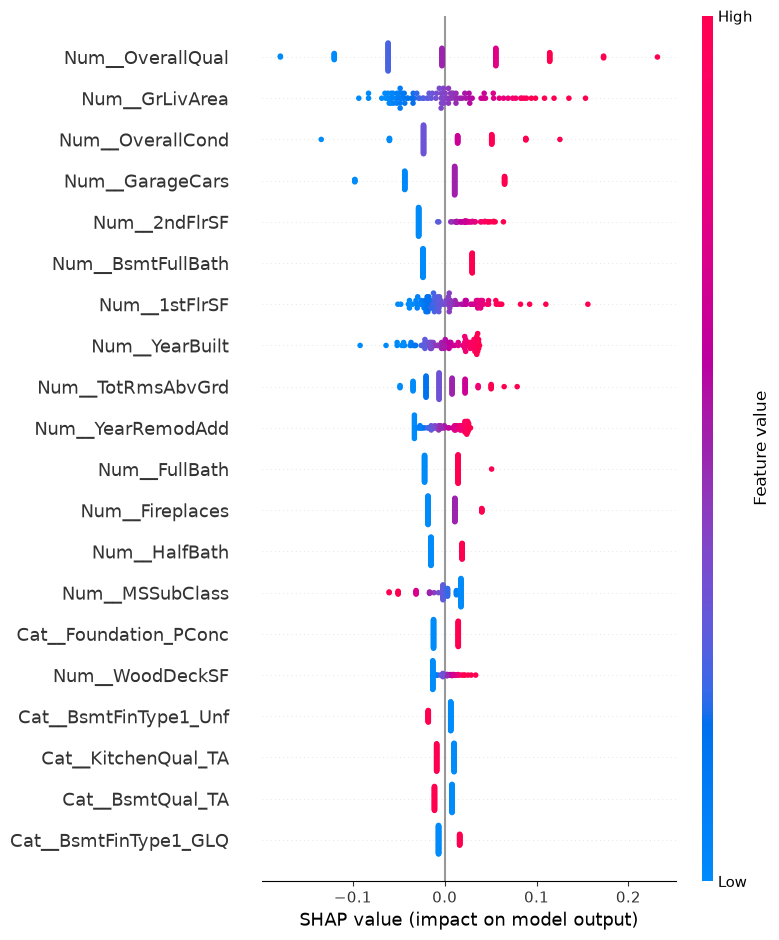

In [ ]:
import shap

# Preprocessed data
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

# Feature names created by one-hot encoding
feature_name = preprocessor.get_feature_names_out()

# Train the best Ridge model on the processed data
final_model = Ridge(alpha = 50)
final_model.fit(x_train_transformed , y_train)

# SHAP explainer
explainer = shap.LinearExplainer(final_model , x_train_transformed)
shap_values = explainer(x_test_transformed[:100])  # First 100 samples for speed

# Summary plot
shap.summary_plot(shap_values, x_test_transformed[:100].toarray(), feature_names=feature_name, show=False)
plt.tight_layout()
plt.savefig('images/shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
import joblib
import os

os.makedirs('model' , exist_ok= True)
joblib.dump(best_ridge , 'model/best_pipeline.pkl')

print("Model saved!")

Model Saved!


In [ ]:
y_pred_actual = np.expm1(y_pred_best)
y_test_actual = np.expm1(y_test)

investment_df = pd.DataFrame({
    'Actual Price' : y_test_actual.values,
    'Predicted Price' : y_pred_actual
})

investment_df['investment_score'] = ((investment_df['Predicted Price'] - investment_df['Actual Price']) / investment_df['Actual Price']) * 100
investment_df.head(10)

,Actual Price,Predicted Price,Investment_score
0,154500.0,155746.276512,0.806651
1,325000.0,318051.020858,-2.138147
2,115000.0,105259.841855,-8.469703
3,159000.0,157977.618500,-0.643007
4,315500.0,322805.005387,2.315374
5,75500.0,82918.674074,9.826058
6,311500.0,245104.418482,-21.314793
7,146000.0,147367.154899,0.936407
8,84500.0,80435.450402,-4.810118
9,135500.0,146409.936160,8.051613


In [22]:
import joblib

defaults = {}

for col in X.columns:
    if X[col].dtype in ['int64', 'float']:
        defaults[col] = float(X[col].median())
    else: 
        defaults[col] = X[col].mode()[0]

joblib.dump(defaults, 'model/feature_defaults.pkl')

print("Defaults saved! Total features:", len(defaults))


Defaults saved! Total features: 79
